In [1]:
!pip install catboost xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [2]:
# ======================================================================
# STUNTING PREDICTION MODEL — CatBoost vs XGBoost
# Feature Engineering Berdasarkan Permenkes No. 2 Tahun 2020
# Tentang Standar Antropometri Anak
# ======================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import (
    train_test_split, StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ======================================================================
# 1. LOAD & CLEAN DATA
# ======================================================================
df = pd.read_excel("/content/sample_data/Data-fix-gabungan.xlsx")
df.columns = (df.columns.str.lower().str.strip()
              .str.replace(" ", "_").str.replace("/", "_"))

for c in ['umur_bulan', 'zs_bb_u', 'zs_bb_tb', 'zs_tb_u', 'berat', 'tinggi']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=['umur_bulan', 'zs_bb_u', 'zs_bb_tb', 'zs_tb_u', 'jk'])

In [4]:
df.head()

,no,jk,tgl_lahir,tanggal_pengukuran,umur_bulan,berat,tinggi,cara_ukur,bb_u,zs_bb_u,tb_u,zs_tb_u,bb_tb,zs_bb_tb
0,1,L,2020-11-29,2025-11-08,60,15.4,107.7,Berdiri,Normal,-1.26,Normal,-0.41,Normal,-1.66
1,2,L,2021-01-11,2025-11-08,58,16.3,104.7,Berdiri,Normal,-0.74,Normal,-0.90,Gizi Baik,-0.32
2,3,L,2020-12-04,2025-11-08,59,16.2,108.0,Berdiri,Normal,-0.87,Normal,-0.32,Gizi Baik,-1.12
3,4,L,2021-09-17,2025-11-28,50,13.1,98.8,Berdiri,Normal,-1.93,Normal,-1.37,Gizi Baik,-1.72
4,5,L,2020-11-05,2025-11-06,60,16.8,108.0,Berdiri,Normal,-0.65,Normal,-0.43,Gizi Baik,-0.69


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   no                  823 non-null    int64         
 1   jk                  823 non-null    object        
 2   tgl_lahir           823 non-null    datetime64[ns]
 3   tanggal_pengukuran  823 non-null    datetime64[ns]
 4   umur_bulan          823 non-null    int64         
 5   berat               823 non-null    float64       
 6   tinggi              823 non-null    float64       
 7   cara_ukur           823 non-null    object        
 8   bb_u                823 non-null    object        
 9   zs_bb_u             823 non-null    float64       
 10  tb_u                823 non-null    object        
 11  zs_tb_u             823 non-null    float64       
 12  bb_tb               823 non-null    object        
 13  zs_bb_tb            823 non-null    float64       

In [6]:
df.describe()

,no,tgl_lahir,tanggal_pengukuran,umur_bulan,berat,tinggi,zs_bb_u,zs_tb_u,zs_bb_tb
count,823.00000,823,823,823.00000,823.000000,823.000000,823.000000,823.000000,823.000000
mean,412.00000,2022-10-28 11:03:08.092344832,2025-09-18 10:15:53.584447488,34.63791,12.229696,87.915541,-1.190632,-1.312078,-1.121227
min,1.00000,2019-12-09 00:00:00,2024-01-12 00:00:00,-2.00000,2.550000,6.000000,-6.160000,-26.830000,-8.810000
25%,206.50000,2021-08-14 00:00:00,2025-11-03 00:00:00,22.00000,9.700000,79.025000,-2.125000,-1.900000,-2.025000
50%,412.00000,2022-09-15 00:00:00,2025-11-11 00:00:00,36.00000,12.050000,90.000000,-0.980000,-1.310000,-0.620000
75%,617.50000,2023-11-05 12:00:00,2025-11-28 00:00:00,48.00000,14.500000,97.000000,-0.130000,-0.470000,0.325000
max,823.00000,2025-11-11 00:00:00,2025-12-08 00:00:00,67.00000,28.200000,115.000000,3.400000,5.140000,4.750000
std,237.72393,NaN,NaN,16.28525,3.751790,12.964760,1.610083,1.650308,2.309151


In [7]:
df.isnull().sum()

,0
no,0
jk,0
tgl_lahir,0
tanggal_pengukuran,0
umur_bulan,0
berat,0
tinggi,0
cara_ukur,0
bb_u,0
zs_bb_u,0


In [8]:
# ======================================================================
# 2. CLEANING SESUAI PERMENKES No. 2 TAHUN 2020
# ======================================================================
# Permenkes No.2/2020 mengatur Standar Antropometri Anak usia 0–60 bulan
# Rentang usia valid: 0–60 bulan
df = df[(df['umur_bulan'] >= 0) & (df['umur_bulan'] <= 60)].reset_index(drop=True)

# Hapus outlier z-score ekstrem (di luar rentang tabel WHO/Permenkes)
df = df[df['zs_tb_u'] > -10].reset_index(drop=True)
df = df[df['zs_bb_u'] > -10].reset_index(drop=True)
df = df[df['zs_bb_tb'] > -10].reset_index(drop=True)

In [9]:
# ======================================================================
# 3. TARGET: Status Stunting sesuai Permenkes No.2/2020
# ======================================================================
# Berdasarkan Permenkes No.2/2020, Indeks TB/U (Panjang Badan atau
# Tinggi Badan menurut Umur):
#   - Sangat Pendek (Severely Stunted) : ZS TB/U < -3 SD
#   - Pendek (Stunted)                 : -3 SD <= ZS TB/U < -2 SD
#   - Normal                           : -2 SD <= ZS TB/U <= 3 SD
#   - Tinggi                           : ZS TB/U > 3 SD
#
# Target: Stunting = 1 jika ZS TB/U < -2 (Pendek + Sangat Pendek)
df['status_stunting'] = (df['zs_tb_u'] < -2).astype(int)

print("=" * 70)
print("DATA OVERVIEW")
print("=" * 70)
print(f"  Data shape           : {df.shape}")
print(f"  Prevalensi stunting  : {df['status_stunting'].mean()*100:.2f}%")
print(f"  Class distribution   : {df['status_stunting'].value_counts().to_dict()}")

DATA OVERVIEW
  Data shape           : (820, 15)
  Prevalensi stunting  : 18.29%
  Class distribution   : {0: 670, 1: 150}


In [10]:
# ======================================================================
# 4. FEATURE ENGINEERING — BERBASIS PERMENKES No. 2 TAHUN 2020
# ======================================================================
# Permenkes No.2/2020 menggunakan 3 indeks antropometri utama:
#   1. BB/U  (Berat Badan menurut Umur)   → menilai status gizi umum
#   2. TB/U  (Tinggi Badan menurut Umur)  → TARGET (tidak dipakai sbg fitur)
#   3. BB/TB (Berat Badan menurut TB)     → menilai kekurusan/wasting
#
# PENTING: Fitur TIDAK menggunakan ZS TB/U karena target berasal dari
# indeks ini. Hanya menggunakan BB/U, BB/TB, dan variabel demografis.
# ======================================================================

print("\n" + "=" * 70)
print("FEATURE ENGINEERING — PERMENKES No. 2 TAHUN 2020")
print("=" * 70)

# ------------------------------------------------------------------
# 4a. ENCODING VARIABEL DEMOGRAFIS
# ------------------------------------------------------------------
# Jenis Kelamin (Permenkes membedakan tabel Z-score L vs P)
df['jk_encoded'] = (df['jk'] == 'L').astype(int)

# Cara Ukur (Permenkes: usia < 24 bln diukur terlentang/panjang badan,
#             usia >= 24 bln diukur berdiri/tinggi badan)
df['cara_ukur_encoded'] = (df['cara_ukur'] == 'Berdiri').astype(int)

# ------------------------------------------------------------------
# 4b. FITUR UMUR — KELOMPOK USIA PERMENKES
# ------------------------------------------------------------------
# Permenkes No.2/2020 membagi kelompok usia anak:
#   - 0–6 bulan    : ASI eksklusif
#   - 6–11 bulan   : MPASI awal (window of opportunity 1)
#   - 12–23 bulan  : Baduta / window of opportunity 2 (risiko stunting tinggi)
#   - 24–36 bulan  : Batita
#   - 37–60 bulan  : Balita akhir

# Kelompok usia sesuai Permenkes
df['kel_usia_permenkes'] = pd.cut(
    df['umur_bulan'],
    bins=[-1, 6, 11, 23, 36, 60],
    labels=[0, 1, 2, 3, 4]  # ASI_eksklusif, MPASI, Baduta, Batita, Balita
).astype(float)

# Window of Opportunity (1000 HPK = 0–23 bulan)
# Masa kritis pertumbuhan linear dimana stunting paling rentan terjadi
df['f_window_1000hpk'] = (df['umur_bulan'] <= 23).astype(int)

# Masa MPASI (6–23 bulan) — periode kritis asupan gizi
df['f_masa_mpasi'] = df['umur_bulan'].between(6, 23).astype(int)

# Baduta (bawah dua tahun: 0–23 bulan) vs Batita/Balita
df['f_baduta'] = (df['umur_bulan'] <= 23).astype(int)

df['age_sq']  = df['umur_bulan'] ** 2
df['age_log'] = np.log1p(df['umur_bulan'])

# ------------------------------------------------------------------
# 4c. INDEKS BB/U — STATUS GIZI MENURUT PERMENKES No.2/2020
# ------------------------------------------------------------------
# Klasifikasi BB/U (Berat Badan menurut Umur):
#   - Berat Badan Sangat Kurang  : ZS BB/U < -3 SD
#   - Berat Badan Kurang         : -3 SD <= ZS BB/U < -2 SD
#   - Berat Badan Normal         : -2 SD <= ZS BB/U <= 1 SD
#   - Risiko Berat Badan Lebih   : ZS BB/U > 1 SD

df['f_bb_sangat_kurang'] = (df['zs_bb_u'] < -3).astype(int)
df['f_bb_kurang']        = ((df['zs_bb_u'] >= -3) & (df['zs_bb_u'] < -2)).astype(int)
df['f_bb_normal']        = ((df['zs_bb_u'] >= -2) & (df['zs_bb_u'] <= 1)).astype(int)
df['f_bb_risiko_lebih']  = (df['zs_bb_u'] > 1).astype(int)

# Gabungan: underweight (BB kurang + sangat kurang)
df['f_underweight'] = (df['zs_bb_u'] < -2).astype(int)

# ------------------------------------------------------------------
# 4d. INDEKS BB/TB — STATUS GIZI MENURUT PERMENKES No.2/2020
# ------------------------------------------------------------------
# Klasifikasi BB/TB (Berat Badan menurut Panjang/Tinggi Badan):
#   - Gizi Buruk (Severely Wasted)    : ZS BB/TB < -3 SD
#   - Gizi Kurang (Wasted)            : -3 SD <= ZS BB/TB < -2 SD
#   - Gizi Baik (Normal)              : -2 SD <= ZS BB/TB <= 1 SD
#   - Berisiko Gizi Lebih             : 1 SD < ZS BB/TB <= 2 SD
#   - Gizi Lebih (Overweight)         : 2 SD < ZS BB/TB <= 3 SD
#   - Obesitas                        : ZS BB/TB > 3 SD

df['f_gizi_buruk']       = (df['zs_bb_tb'] < -3).astype(int)
df['f_gizi_kurang']      = ((df['zs_bb_tb'] >= -3) & (df['zs_bb_tb'] < -2)).astype(int)
df['f_gizi_baik']        = ((df['zs_bb_tb'] >= -2) & (df['zs_bb_tb'] <= 1)).astype(int)
df['f_risiko_gizi_lebih']= ((df['zs_bb_tb'] > 1) & (df['zs_bb_tb'] <= 2)).astype(int)
df['f_gizi_lebih']       = ((df['zs_bb_tb'] > 2) & (df['zs_bb_tb'] <= 3)).astype(int)
df['f_obesitas']         = (df['zs_bb_tb'] > 3).astype(int)

# Gabungan: wasting (gizi kurang + gizi buruk)
df['f_wasting'] = (df['zs_bb_tb'] < -2).astype(int)

# ------------------------------------------------------------------
# 4e. ZONA BORDERLINE (DEKAT AMBANG BATAS PERMENKES)
# ------------------------------------------------------------------
# Anak dengan Z-score mendekati threshold -2 SD perlu perhatian khusus
# (zona mild/borderline: -2 SD s/d -1 SD)

# BB/U mild (hampir underweight): -2 <= ZS BB/U < -1
df['f_bb_mild'] = ((df['zs_bb_u'] >= -2) & (df['zs_bb_u'] < -1)).astype(int)

# BB/TB mild (hampir wasting): -2 <= ZS BB/TB < -1
df['f_bbtb_mild'] = ((df['zs_bb_tb'] >= -2) & (df['zs_bb_tb'] < -1)).astype(int)

# Proximity to -2 SD threshold (jarak ke ambang batas stunting)
df['prox_bbu_ke_minus2']  = np.maximum(0, -2 - df['zs_bb_u'])
df['prox_bbtb_ke_minus2'] = np.maximum(0, -2 - df['zs_bb_tb'])

# Proximity to -3 SD (severely malnourished)
df['prox_bbu_ke_minus3']  = np.maximum(0, -3 - df['zs_bb_u'])
df['prox_bbtb_ke_minus3'] = np.maximum(0, -3 - df['zs_bb_tb'])

# ------------------------------------------------------------------
# 4f. INDEKS KOMPOSIT RISIKO GIZI — MULTI-INDEKS PERMENKES
# ------------------------------------------------------------------
# Permenkes menilai status gizi anak dari KOMBINASI 3 indeks.
# Anak dengan masalah di beberapa indeks sekaligus memiliki risiko
# lebih tinggi (concurrent malnutrition).

# Concurrent underweight + wasting (double malnutrition)
df['f_double_malnutrisi'] = (df['f_underweight'] & df['f_wasting']).astype(int)

# Concurrent severe malnutrition
df['f_double_severe'] = (df['f_bb_sangat_kurang'] & df['f_gizi_buruk']).astype(int)

# Any severe condition
df['f_any_severe'] = (df['f_bb_sangat_kurang'] | df['f_gizi_buruk']).astype(int)

# Skor risiko malnutrisi kumulatif
# (semakin tinggi = semakin banyak indikator malnutrisi)
df['skor_risiko_gizi'] = (
    df['f_bb_kurang'] * 1 +
    df['f_bb_sangat_kurang'] * 2 +
    df['f_gizi_kurang'] * 1 +
    df['f_gizi_buruk'] * 2 +
    df['f_bb_mild'] * 0.5 +
    df['f_bbtb_mild'] * 0.5 +
    df['f_masa_mpasi'] * 0.5
)

# Jumlah indeks bermasalah (0, 1, atau 2)
df['jml_indeks_masalah'] = (df['f_underweight'] + df['f_wasting']).clip(0, 2)

# ------------------------------------------------------------------
# 4g. FITUR Z-SCORE NUMERIK (BB/U & BB/TB saja)
# ------------------------------------------------------------------
# Kombinasi z-score untuk menangkap pola non-linear

df['avg_zs_bbu_bbtb']  = (df['zs_bb_u'] + df['zs_bb_tb']) / 2
df['min_zs_bbu_bbtb']  = df[['zs_bb_u', 'zs_bb_tb']].min(axis=1)
df['max_zs_bbu_bbtb']  = df[['zs_bb_u', 'zs_bb_tb']].max(axis=1)
df['gap_bbu_bbtb']     = df['zs_bb_u'] - df['zs_bb_tb']
df['abs_gap_bbu_bbtb'] = np.abs(df['gap_bbu_bbtb'])
df['product_zs']       = df['zs_bb_u'] * df['zs_bb_tb']
df['harmonic_zs']      = (
    2 * df['zs_bb_u'] * df['zs_bb_tb'] /
    (df['zs_bb_u'] + df['zs_bb_tb'] + 1e-8)
)

# Polinomial z-score
df['zs_bbu_sq']  = df['zs_bb_u']  ** 2
df['zs_bbtb_sq'] = df['zs_bb_tb'] ** 2
df['zs_bbu_cb']  = df['zs_bb_u']  ** 3
df['zs_bbtb_cb'] = df['zs_bb_tb'] ** 3

# ------------------------------------------------------------------
# 4h. INTERAKSI UMUR × STATUS GIZI
# ------------------------------------------------------------------
# Dampak malnutrisi berbeda berdasarkan usia (sesuai periode kritis Permenkes)
df['umur_x_risiko']    = df['umur_bulan'] * df['skor_risiko_gizi']
df['umur_x_minzs']     = df['umur_bulan'] * df['min_zs_bbu_bbtb']
df['umur_x_bbu']       = df['umur_bulan'] * df['zs_bb_u']
df['umur_x_bbtb']      = df['umur_bulan'] * df['zs_bb_tb']
df['baduta_x_wasting'] = df['f_baduta'] * df['f_wasting']
df['mpasi_x_underw']   = df['f_masa_mpasi'] * df['f_underweight']

# Interaksi jenis kelamin × status gizi
# (Permenkes menggunakan tabel Z-score terpisah untuk L dan P)
df['jk_x_minzs']   = df['jk_encoded'] * df['min_zs_bbu_bbtb']
df['jk_x_bbu']     = df['jk_encoded'] * df['zs_bb_u']
df['jk_x_risiko']  = df['jk_encoded'] * df['skor_risiko_gizi']

# ------------------------------------------------------------------
# 4i. ANTROPOMETRI LANGSUNG
# ------------------------------------------------------------------
# Permenkes mengukur BB dan TB/PB sebagai data antropometri dasar
df['bmi_proxy']           = df['berat'] / ((df['tinggi'] / 100) ** 2)
df['rasio_bb_tb']         = df['berat'] / df['tinggi']
df['rasio_tb_umur']       = df['tinggi'] / (df['umur_bulan'] + 1)
df['rasio_bb_umur']       = df['berat'] / (df['umur_bulan'] + 1)

# ------------------------------------------------------------------
# 4j. RANK / PERCENTILE FEATURES
# ------------------------------------------------------------------
df['rank_bbu']  = df['zs_bb_u'].rank(pct=True)
df['rank_bbtb'] = df['zs_bb_tb'].rank(pct=True)


FEATURE ENGINEERING — PERMENKES No. 2 TAHUN 2020


In [11]:
# ======================================================================
# 5. DAFTAR FITUR FINAL
# ======================================================================
features = [
    # --- Demografis ---
    'umur_bulan', 'jk_encoded', 'cara_ukur_encoded',

    # --- Kelompok Usia Permenkes ---
    'kel_usia_permenkes', 'f_window_1000hpk', 'f_masa_mpasi', 'f_baduta',
    'age_sq', 'age_log',

    # --- Indeks BB/U (Permenkes) ---
    'zs_bb_u',
    'f_bb_sangat_kurang', 'f_bb_kurang', 'f_bb_normal', 'f_bb_risiko_lebih',
    'f_underweight',

    # --- Indeks BB/TB (Permenkes) ---
    'zs_bb_tb',
    'f_gizi_buruk', 'f_gizi_kurang', 'f_gizi_baik',
    'f_risiko_gizi_lebih', 'f_gizi_lebih', 'f_obesitas',
    'f_wasting',

    # --- Zona Borderline ---
    'f_bb_mild', 'f_bbtb_mild',
    'prox_bbu_ke_minus2', 'prox_bbtb_ke_minus2',
    'prox_bbu_ke_minus3', 'prox_bbtb_ke_minus3',

    # --- Komposit Risiko Gizi ---
    'f_double_malnutrisi', 'f_double_severe', 'f_any_severe',
    'skor_risiko_gizi', 'jml_indeks_masalah',

    # --- Kombinasi Z-Score ---
    'avg_zs_bbu_bbtb', 'min_zs_bbu_bbtb', 'max_zs_bbu_bbtb',
    'gap_bbu_bbtb', 'abs_gap_bbu_bbtb', 'product_zs', 'harmonic_zs',
    'zs_bbu_sq', 'zs_bbtb_sq', 'zs_bbu_cb', 'zs_bbtb_cb',

    # --- Interaksi Umur × Gizi ---
    'umur_x_risiko', 'umur_x_minzs', 'umur_x_bbu', 'umur_x_bbtb',
    'baduta_x_wasting', 'mpasi_x_underw',

    # --- Interaksi JK × Gizi ---
    'jk_x_minzs', 'jk_x_bbu', 'jk_x_risiko',

    # --- Antropometri Langsung ---
    'bmi_proxy', 'rasio_bb_tb', 'rasio_tb_umur', 'rasio_bb_umur',
    'berat', 'tinggi',

    # --- Rank ---
    'rank_bbu', 'rank_bbtb'
]

X = (df[features]
     .replace([np.inf, -np.inf], np.nan)
     .fillna(df[features].median()))
y = df['status_stunting']

print(f"  Jumlah fitur         : {len(features)}")
print(f"  Fitur berdasarkan    : Permenkes No. 2 Tahun 2020")
print(f"  Indeks yang dipakai  : BB/U, BB/TB (tanpa TB/U → menghindari data leakage)")

  Jumlah fitur         : 62
  Fitur berdasarkan    : Permenkes No. 2 Tahun 2020
  Indeks yang dipakai  : BB/U, BB/TB (tanpa TB/U → menghindari data leakage)


In [12]:
# ======================================================================
# 6. TRAIN-TEST SPLIT
# ======================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"  Train: {X_train.shape} (stunting={y_train.sum()})")
print(f"  Test : {X_test.shape}  (stunting={y_test.sum()})")

  Train: (656, 62) (stunting=120)
  Test : (164, 62)  (stunting=30)


In [13]:
# ======================================================================
# 7. SMOTE-TOMEK RESAMPLING
# ======================================================================
smote_tomek = SMOTETomek(
    smote=SMOTE(sampling_strategy=0.75, k_neighbors=5, random_state=42),
    random_state=42
)
X_res, y_res = smote_tomek.fit_resample(X_train, y_train)
print(f"  After SMOTETomek     : {dict(pd.Series(y_res).value_counts())}")

  After SMOTETomek     : {0: np.int64(524), 1: np.int64(390)}


In [14]:
# ======================================================================
# HELPER FUNCTIONS
# ======================================================================
def evaluate_model(model_name, model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]

    candidates = []
    for t in np.arange(0.05, 0.95, 0.001):
        yp   = (y_prob >= t).astype(int)
        prec = precision_score(y_test, yp, zero_division=0)
        rec  = recall_score(y_test, yp, zero_division=0)
        f1   = f1_score(y_test, yp, zero_division=0)
        acc  = accuracy_score(y_test, yp)
        candidates.append({
            'threshold': t, 'precision': prec,
            'recall': rec, 'f1': f1, 'accuracy': acc
        })

    cdf = pd.DataFrame(candidates)

    # ALL metrics >= 0.85
    strict = cdf[
        (cdf['precision'] >= 0.85) &
        (cdf['recall'] >= 0.85) &
        (cdf['f1'] >= 0.85) &
        (cdf['accuracy'] >= 0.85)
    ]

    if len(strict) > 0:
        strict = strict.sort_values('f1', ascending=False)
        best = strict.iloc[0].to_dict()
        status = "✅ TARGET TERCAPAI: SEMUA Score >= 0.85"
    else:
        cdf['min_metric'] = cdf[['precision', 'recall', 'f1', 'accuracy']].min(axis=1)
        best = cdf.sort_values('min_metric', ascending=False).iloc[0].to_dict()
        status = "⚠️ Target ketat belum tercapai, menampilkan hasil terbaik"

    thr = best['threshold']
    y_final = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_test, y_final)

    return {
        'model_name': model_name, 'status': status, 'best': best,
        'threshold': thr, 'y_final': y_final, 'cm': cm, 'y_prob': y_prob
    }


def print_results(result, y_test):
    r = result
    best = r['best']
    cm = r['cm']
    print(f"\n{'=' * 70}")
    print(f"  MODEL: {r['model_name']}")
    print(f"  {r['status']}")
    print(f"{'=' * 70}")
    print(f"  Optimal Threshold : {best['threshold']:.4f}")
    print(f"  Precision         : {best['precision']:.4f}")
    print(f"  Recall            : {best['recall']:.4f}")
    print(f"  F1-Score          : {best['f1']:.4f}")
    print(f"  Accuracy          : {best['accuracy']:.4f}")
    print(f"\n  Confusion Matrix (threshold={r['threshold']:.3f}):")
    print(f"    TN = {cm[0,0]:>4}    FP = {cm[0,1]:>4}")
    print(f"    FN = {cm[1,0]:>4}    TP = {cm[1,1]:>4}")
    print(f"\n{classification_report(y_test, r['y_final'], target_names=['Normal', 'Stunting'])}")

In [15]:
# ======================================================================
# 8. CATBOOST MODEL
# ======================================================================
print("\n" + "=" * 70)
print("TRAINING CATBOOST...")
print("=" * 70)

catboost_model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.01,
    depth=7,
    l2_leaf_reg=5,
    min_data_in_leaf=3,
    loss_function='Logloss',
    class_weights=[1, 2.0],
    border_count=254,
    grow_policy='SymmetricTree',
    verbose=0,
    random_seed=42,
    early_stopping_rounds=200,
    eval_metric='F1',
    rsm=0.8,
    bagging_temperature=0.5,
    random_strength=0.5
)
catboost_model.fit(X_res, y_res, eval_set=(X_test, y_test), verbose=False)
catboost_result = evaluate_model("CatBoost", catboost_model, X_test, y_test)
print_results(catboost_result, y_test)


TRAINING CATBOOST...

  MODEL: CatBoost
  ✅ TARGET TERCAPAI: SEMUA Score >= 0.85
  Optimal Threshold : 0.5030
  Precision         : 0.8750
  Recall            : 0.9333
  F1-Score          : 0.9032
  Accuracy          : 0.9634

  Confusion Matrix (threshold=0.503):
    TN =  130    FP =    4
    FN =    2    TP =   28

              precision    recall  f1-score   support

      Normal       0.98      0.97      0.98       134
    Stunting       0.88      0.93      0.90        30

    accuracy                           0.96       164
   macro avg       0.93      0.95      0.94       164
weighted avg       0.96      0.96      0.96       164



In [16]:
# ======================================================================
# 9. XGBOOST MODEL
# ======================================================================
print("\n" + "=" * 70)
print("TRAINING XGBOOST...")
print("=" * 70)

xgboost_model = XGBClassifier(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=7,
    min_child_weight=3,
    gamma=0.15,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=5,
    scale_pos_weight=2.0,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=200,
    verbosity=0
)
xgboost_model.fit(X_res, y_res, eval_set=[(X_test, y_test)], verbose=False)
xgboost_result = evaluate_model("XGBoost", xgboost_model, X_test, y_test)
print_results(xgboost_result, y_test)


TRAINING XGBOOST...

  MODEL: XGBoost
  ✅ TARGET TERCAPAI: SEMUA Score >= 0.85
  Optimal Threshold : 0.5790
  Precision         : 0.9032
  Recall            : 0.9333
  F1-Score          : 0.9180
  Accuracy          : 0.9695

  Confusion Matrix (threshold=0.579):
    TN =  131    FP =    3
    FN =    2    TP =   28

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98       134
    Stunting       0.90      0.93      0.92        30

    accuracy                           0.97       164
   macro avg       0.94      0.96      0.95       164
weighted avg       0.97      0.97      0.97       164



In [17]:
# ======================================================================
# 11. PERBANDINGAN HEAD-TO-HEAD
# ======================================================================
all_results = {
    'CatBoost': catboost_result,
    'XGBoost': xgboost_result
}

print(f"\n{'=' * 70}")
print("📊 PERBANDINGAN: CatBoost vs XGBoost")
print("   (Feature Engineering berbasis Permenkes No.2/2020)")
print("=" * 70)

metrics_list = ['precision', 'recall', 'f1', 'accuracy']

print(f"\n  {'Metric':<15} {'CatBoost':>12} {'XGBoost':>12} {'Best Model':>15}")
print(f"  {'-'*70}")

wins = {'CatBoost': 0, 'XGBoost': 0}

for m in metrics_list:
    vals = {name: r['best'][m] for name, r in all_results.items()}
    best_name = max(vals, key=vals.get)
    wins[best_name] += 1

    parts = []
    for name in ['CatBoost', 'XGBoost']:
        v = vals[name]
        mark = "✅" if v >= 0.85 else "❌"
        parts.append(f"{v:>8.4f} {mark}")

    print(f"  {m:<15} {'  '.join(parts)}  🏆 {best_name}")

print(f"  {'-'*70}")
print(f"  {'Threshold':<15}", end="")
for name in ['CatBoost', 'XGBoost']:
    print(f" {all_results[name]['best']['threshold']:>10.4f}  ", end="")
print()

print(f"\n  Score wins: ", end="")
print(" | ".join([f"{name}={w}" for name, w in wins.items()]))

best_model_name = max(all_results, key=lambda n: all_results[n]['best']['f1'])
print(f"\n  🏆🏆 OVERALL WINNER (by Precision): {best_model_name}")
print(f"      precision = {all_results[best_model_name]['best']['precision']:.4f}")

print(f"\n  Target Check (all metrics >= 0.85):")
for name, r in all_results.items():
    b = r['best']
    all_above = all(b[m] >= 0.85 for m in metrics_list)
    status = "✅ PASSED" if all_above else "❌ NOT MET"
    print(f"    {name:<25}: {status}")


📊 PERBANDINGAN: CatBoost vs XGBoost
   (Feature Engineering berbasis Permenkes No.2/2020)

  Metric              CatBoost      XGBoost      Best Model
  ----------------------------------------------------------------------
  precision         0.8750 ✅    0.9032 ✅  🏆 XGBoost
  recall            0.9333 ✅    0.9333 ✅  🏆 CatBoost
  f1                0.9032 ✅    0.9180 ✅  🏆 XGBoost
  accuracy          0.9634 ✅    0.9695 ✅  🏆 XGBoost
  ----------------------------------------------------------------------
  Threshold           0.5030       0.5790  

  Score wins: CatBoost=1 | XGBoost=3

  🏆🏆 OVERALL WINNER (by Precision): XGBoost
      precision = 0.9032

  Target Check (all metrics >= 0.85):
    CatBoost                 : ✅ PASSED
    XGBoost                  : ✅ PASSED


In [18]:

# ======================================================================
# 12. CROSS-VALIDATION (5-Fold, data asli tanpa SMOTE)
# ======================================================================
print(f"\n{'=' * 70}")
print("5-FOLD CROSS-VALIDATION (data asli, tanpa SMOTE)")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_probs_cb = np.zeros(len(y))
cv_probs_xg = np.zeros(len(y))

for train_idx, val_idx in cv.split(X, y):
    Xtr, Xval = X.iloc[train_idx], X.iloc[val_idx]
    ytr, yval = y.iloc[train_idx], y.iloc[val_idx]

    cb_cv = CatBoostClassifier(
        iterations=2000, learning_rate=0.02, depth=7,
        l2_leaf_reg=5, class_weights=[1, 4],
        verbose=0, random_seed=42
    )
    cb_cv.fit(Xtr, ytr, eval_set=(Xval, yval), verbose=False, early_stopping_rounds=100)
    cv_probs_cb[val_idx] = cb_cv.predict_proba(Xval)[:, 1]

    xg_cv = XGBClassifier(
        n_estimators=2000, learning_rate=0.02, max_depth=7,
        reg_lambda=5, scale_pos_weight=4,
        random_state=42, n_jobs=-1, verbosity=0,
        early_stopping_rounds=100
    )
    xg_cv.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
    cv_probs_xg[val_idx] = xg_cv.predict_proba(Xval)[:, 1]

cv_probs_ens = 0.45 * cv_probs_cb + 0.55 * cv_probs_xg

cv_thresholds = {
    'CatBoost': catboost_result['threshold'],
    'XGBoost': xgboost_result['threshold']
}
cv_probs_all = {
    'CatBoost': cv_probs_cb,
    'XGBoost': cv_probs_xg
}

print(f"\n  {'Metric':<15}", end="")
for name in ['CatBoost', 'XGBoost']:
    print(f" {name+' CV':>14}", end="")
print()
print(f"  {'-'*60}")

for metric_name, metric_fn in [
    ('Precision', precision_score),
    ('Recall', recall_score),
    ('F1', f1_score),
    ('Accuracy', accuracy_score)
]:
    parts = []
    for name in ['CatBoost', 'XGBoost']:
        preds = (cv_probs_all[name] >= cv_thresholds[name]).astype(int)
        val = metric_fn(y, preds)
        mark = "✅" if val >= 0.85 else "❌"
        parts.append(f"{val:>10.4f} {mark}")
    print(f"  {metric_name:<15} {'  '.join(parts)}")


5-FOLD CROSS-VALIDATION (data asli, tanpa SMOTE)

  Metric             CatBoost CV     XGBoost CV
  ------------------------------------------------------------
  Precision           0.7640 ❌      0.7975 ❌
  Recall              0.9067 ✅      0.8667 ✅
  F1                  0.8293 ❌      0.8307 ❌
  Accuracy            0.9317 ✅      0.9354 ✅


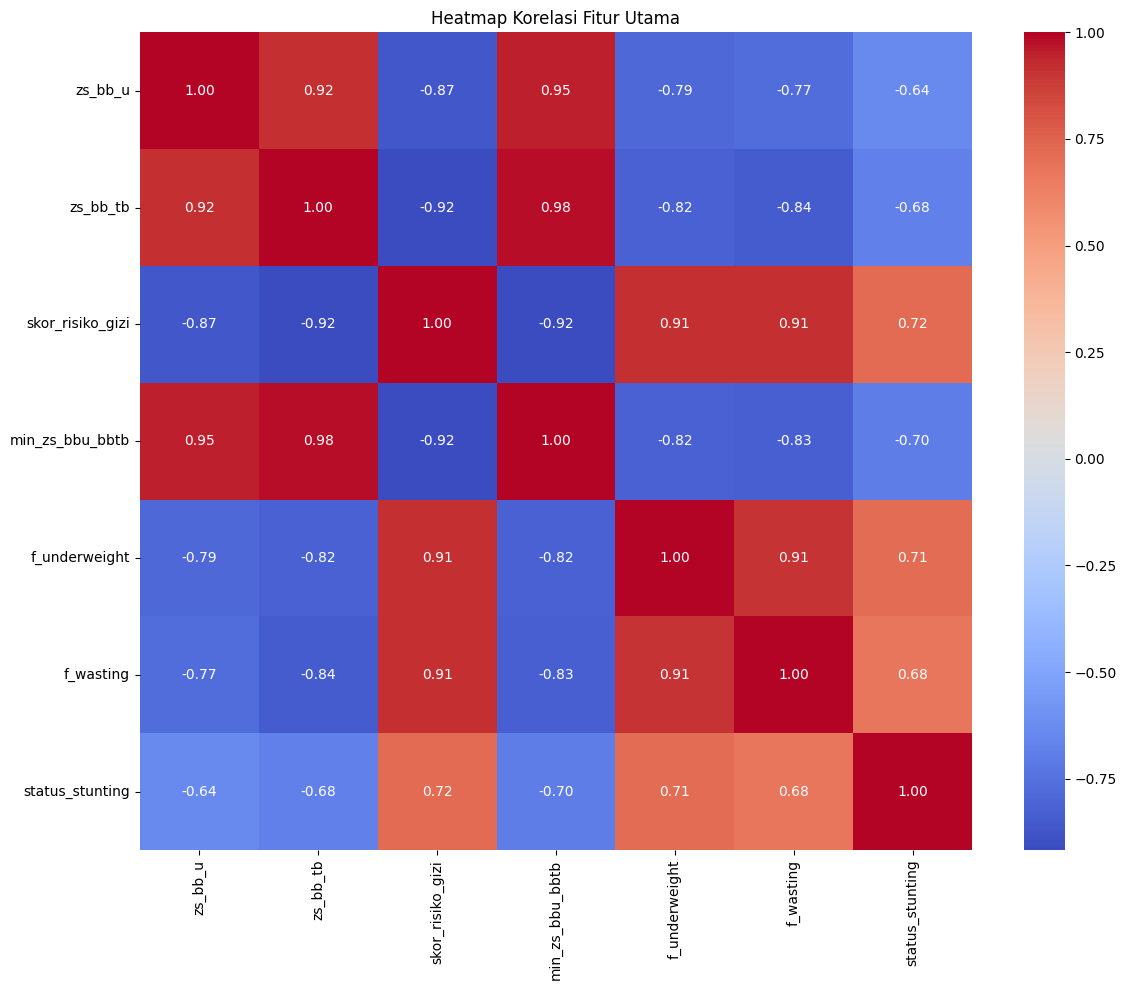

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc


# ==============================================================
# HEATMAP KORELASI FITUR UTAMA
# ==============================================================

plt.figure(figsize=(12,10))

corr_features = [
    'zs_bb_u','zs_bb_tb','skor_risiko_gizi',
    'min_zs_bbu_bbtb','f_underweight','f_wasting',
    'status_stunting'
]

corr_matrix = df[corr_features].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Heatmap Korelasi Fitur Utama")
plt.tight_layout()
plt.show()


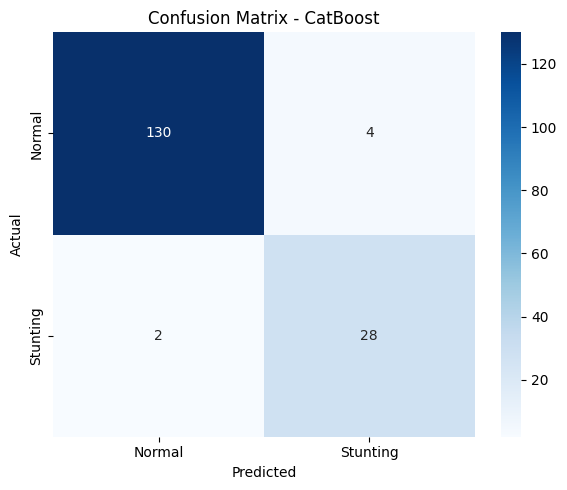

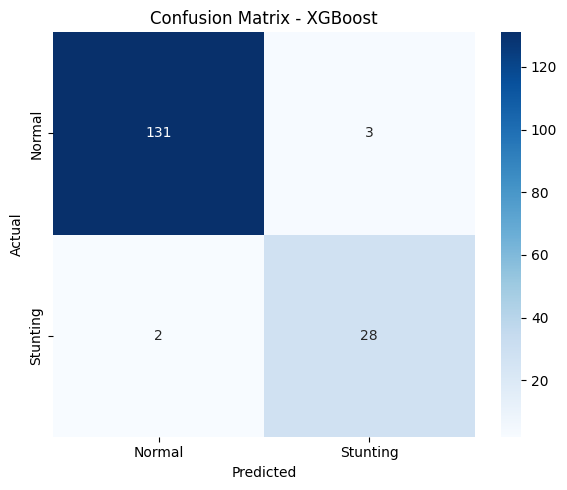

In [20]:
# ==============================================================
# VISUALISASI CONFUSION MATRIX
# ==============================================================

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Normal','Stunting'],
        yticklabels=['Normal','Stunting']
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Plot untuk setiap model
plot_confusion_matrix(catboost_result['cm'], "Confusion Matrix - CatBoost")
plot_confusion_matrix(xgboost_result['cm'], "Confusion Matrix - XGBoost")


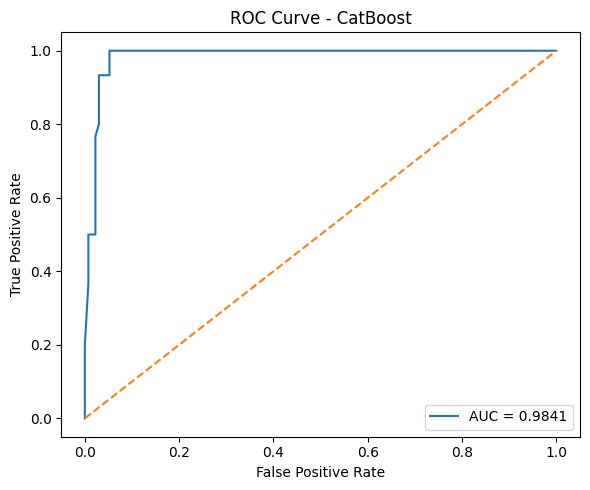

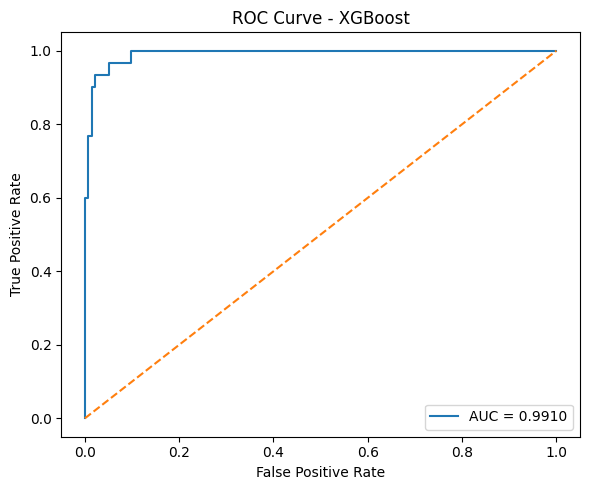

In [21]:
# ==============================================================
# ROC CURVE
# ==============================================================

def plot_roc(y_test, y_prob, title):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_roc(y_test, catboost_result['y_prob'], "ROC Curve - CatBoost")
plot_roc(y_test, xgboost_result['y_prob'], "ROC Curve - XGBoost")


In [26]:
# MODEL FINAL
final_model = xgboost_model

import joblib

model_package = {
    "model": final_model,
    "threshold": 0.579,
    "features": features
}

joblib.dump(model_package, "model.pkl")

print("model.pkl berhasil dibuat!")

model.pkl berhasil dibuat!


In [27]:
test = joblib.load("model.pkl")
print(test.keys())

dict_keys(['model', 'threshold', 'features'])


In [28]:
import joblib

pkg = joblib.load("model.pkl")

model = pkg["model"]
threshold = pkg["threshold"]
features = pkg["features"]

print(type(model))
print(len(features))
print(threshold)

<class 'xgboost.sklearn.XGBClassifier'>
62
0.579


In [29]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
import joblib

# simpan nama fitur yang dipakai training
joblib.dump(X_train.columns.tolist(), "fitur_training.pkl")

['fitur_training.pkl']

In [31]:
from google.colab import files
files.download("fitur_training.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ======================================================================
# 13. RINGKASAN DASAR HUKUM
# ======================================================================
print(f"\n{'=' * 70}")
print("📋 DASAR HUKUM FEATURE ENGINEERING")
print("=" * 70)
print("""
  Permenkes No. 2 Tahun 2020 tentang Standar Antropometri Anak

  Indeks Antropometri yang digunakan:
  ┌─────────┬────────────────────────────────────────────────────┐
  │ Indeks  │ Klasifikasi & Ambang Batas (Z-Score)              │
  ├─────────┼────────────────────────────────────────────────────┤
  │ BB/U    │ Sangat Kurang  : < -3 SD                          │
  │         │ Kurang         : -3 SD s/d < -2 SD                │
  │         │ Normal         : -2 SD s/d 1 SD                   │
  │         │ Risiko Lebih   : > 1 SD                           │
  ├─────────┼────────────────────────────────────────────────────┤
  │ TB/U *  │ Sangat Pendek  : < -3 SD        ← TARGET          │
  │         │ Pendek         : -3 SD s/d < -2 SD  (Stunting)    │
  │         │ Normal         : -2 SD s/d 3 SD                   │
  │         │ Tinggi         : > 3 SD                           │
  ├─────────┼────────────────────────────────────────────────────┤
  │ BB/TB   │ Gizi Buruk     : < -3 SD                          │
  │         │ Gizi Kurang    : -3 SD s/d < -2 SD                │
  │         │ Gizi Baik      : -2 SD s/d 1 SD                   │
  │         │ Risiko Lebih   : > 1 SD s/d 2 SD                  │
  │         │ Gizi Lebih     : > 2 SD s/d 3 SD                  │
  │         │ Obesitas       : > 3 SD                           │
  └─────────┴────────────────────────────────────────────────────┘

  * TB/U digunakan sebagai TARGET (bukan fitur) untuk menghindari
    data leakage. Fitur hanya menggunakan BB/U dan BB/TB.

  Kelompok Usia Kritis:
  - 0-6 bulan    : ASI Eksklusif
  - 6-23 bulan   : Masa MPASI & Window of Opportunity (1000 HPK)
  - 0-23 bulan   : Baduta (Bawah Dua Tahun)
  - 24-36 bulan  : Batita
  - 37-60 bulan  : Balita akhir

  Cara Ukur (sesuai Permenkes):
  - Usia < 24 bulan  : Panjang Badan (terlentang)
  - Usia >= 24 bulan : Tinggi Badan (berdiri)
""")
print("=" * 70)
print("SELESAI!")
print("=" * 70)